<a href="https://colab.research.google.com/github/Ahirvoas/Training-Day2/blob/main/Tutorial_day1-Anomaly.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wind Turbine Modeling Workshop

In [ ]:
!pip install gdown &> /dev/null
!gdown https://drive.google.com/uc?id=1h4pa6sSFbgaAi8zHObwtQIDVB8pBXoG

Downloading...
From: https://drive.google.com/uc?id=1MAAFJDEslGNRUQrVEH_leK1R-Tbo1n4M
To: /content/status_data.csv
100% 131k/131k [00:00<00:00, 77.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1tGANUJSnGvMd3NPfcpKINCXkImjwh97m
To: /content/scada_data.csv
100% 14.8M/14.8M [00:00<00:00, 40.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1K8YVo_dctLD9-jK2c2gQv2PFZkNcGirf
To: /content/fault_data.csv
100% 20.5k/20.5k [00:00<00:00, 46.0MB/s]


In this notebook, we have access to a comprehensive dataset. This dataset includes over 60 different parameters or statuses related to the components of wind turbines, all recorded by the Supervisory Control and Data Acquisition (SCADA) system and catalogs various fault types or modes that can occur in wind turbines.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

#### 1. Read data

In [ ]:
dataset = pd.read_csv('dataset_anomalies.csv')

In [ ]:
dataset.head()

In [ ]:
X = dataset.iloc[:,:-1]
y = dataset.iloc[:,-1]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

The fault dataset catalogs various fault types or modes that can occur in wind turbines. Specifically, it includes five types of faults:

* gf: Generator Heating Fault
* mf: Mains Failure Fault
* ff: Feeding Fault
* af: Timeout Warning Message - Malfunction Air Cooling
* ef: Excitation Error - Overvoltage DC-Link

This information is essential for diagnosing and understanding the different failure mechanisms that may affect turbine performance and reliability.

#### 2. Time series analysis

Plot the different time spans corresponding to the three previous datasets stored in the `scada_df`, `fault_df` and `status_df` dataframes.

(0.0, 4.0)

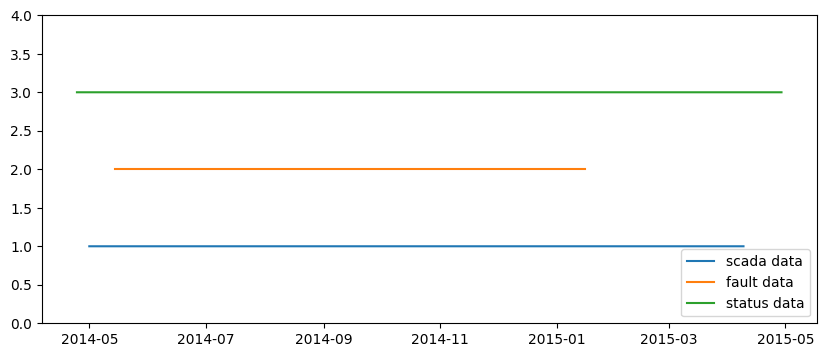

In [10]:
import numpy as np

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(scada_df.DateTime, np.full(len(scada_df), 1), label='scada data')
plt.plot(fault_df.DateTime, np.full(len(fault_df), 2), label='fault data')
plt.plot(status_df.DateTime, np.full(len(status_df), 3), label='status data')
plt.legend(loc='lower right')
plt.ylim(0,4)

Plot the maximum power with the corresponding maximum wind speed from the SCADA stored in the `scada_df` dataframe.

<Axes: xlabel='DateTime'>

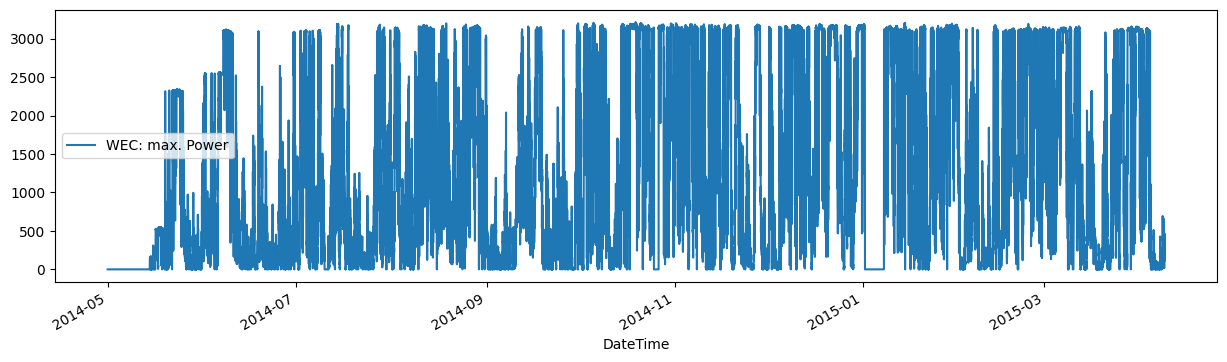

In [11]:
scada_df.plot(x='DateTime', y='WEC: max. Power', figsize=(15,4))

Do the same but by resampling the data weekly

<Axes: xlabel='DateTime'>

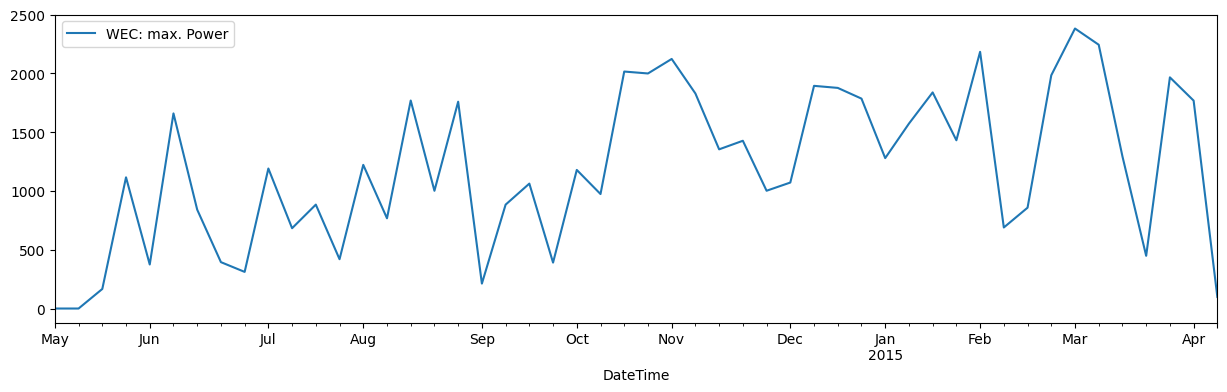

In [12]:
# Plot of max power on weekly resampled data
y = 'WEC: max. Power'
scada_df.resample('W', on='DateTime').mean().plot(y=y, figsize=(15,4))

Plot of number of faults on monthly resampled data

<Axes: xlabel='DateTime'>

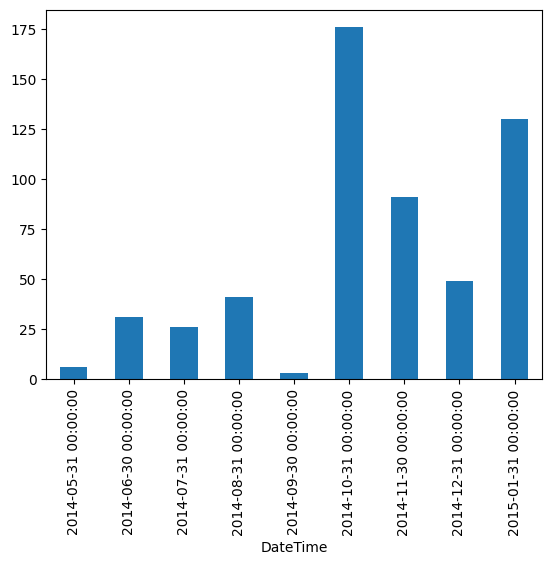

In [13]:
# Plot of number of faults on monthly resampled data
fault_df.resample('ME', on='DateTime').Fault.count().plot.bar()

### 3. Combine SCADA and faults data

Combine SCADA and fault data to pair each measurements with associated faults. To do so, we will use the `merge` function from pandas on Time and with the how='outer' argument.

In [14]:
df_combine = scada_df.merge(fault_df, on='Time', how='outer')


Additionally, there are numerous NaNs, or unmatched SCADA timestamps with fault timestamps, simply because no faults occur at certain times. For these NaNs, we will replace them with "NF", which stands for No Fault (normal condition).

In [15]:
df_combine['Fault'] = df_combine['Fault'].replace(np.nan, 'NF')

Modification to not consider storm and now wind period.

In [16]:

mask = status_df['Status Text'].isin(['Storm : Average windspeed - (10min)', 'Lack of wind : Wind speed to low'])
indexes = status_df.DateTime[mask]

indexes = pd.to_datetime(indexes)  # Convert once
mask = ~df_combine['DateTime_x'].isin(indexes) & ~df_combine['DateTime_y'].isin(indexes)
df_combine = df_combine[mask]

mask = ~(df_combine['WEC: ava. windspeed'] == 0) & \
       ~(df_combine['WEC: max. windspeed'] == 0) & \
       ~(df_combine['WEC: min. windspeed'] == 0)

df_combine = df_combine[mask]
mask = ~(df_combine['WEC: ava. windspeed'] == 0) & \
       ~(df_combine['WEC: ava. Power'] == 0)

df_combine = df_combine[mask]
df_combine.shape
df_combine.head()

,DateTime_x,Time,Error,WEC: ava. windspeed,WEC: max. windspeed,WEC: min. windspeed,WEC: ava. Rotation,WEC: max. Rotation,WEC: min. Rotation,WEC: ava. Power,...,Fan inverter cabinet temp.,Ambient temp.,Tower temp.,Control cabinet temp.,Transformer temp.,RTU: ava. Setpoint 1,Inverter averages,Inverter std dev,DateTime_y,Fault
1951,2014-05-14 15:39:00,1400099968,0,5.9,7.5,3.7,6.56,7.09,1.02,46,...,28,18,22,31,35,2501,27.090910,1.578261,NaT,NF
1952,2014-05-14 15:50:00,1400100608,0,3.8,6.6,0.6,3.37,7.06,0.00,24,...,28,18,20,29,35,2501,27.454546,1.863525,NaT,NF
1953,2014-05-14 16:00:00,1400101248,0,4.1,6.7,1.0,1.69,7.24,0.00,7,...,28,18,19,28,35,2501,27.272728,1.420627,NaT,NF
1954,2014-05-14 16:09:00,1400101760,0,4.1,5.3,2.8,6.82,7.03,6.61,50,...,28,18,18,26,35,2501,27.545454,1.916436,NaT,NF
1955,2014-05-14 16:20:00,1400102400,0,4.2,6.1,2.7,7.35,7.73,6.95,97,...,28,18,18,26,35,2501,27.000000,2.863564,NaT,NF


Print the averages of SCADA values grouped by fault modes.

In [17]:
# Suppress scientific notations
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Group by fault and take average
df_summary = df_combine.groupby('Fault').mean().T
df_summary.tail(20)

Fault,AF,EF,FF,MF,NF
Rotor temp. 1,56.607,100.439,82.187,54.222,56.498
Rotor temp. 2,56.679,99.988,81.968,54.389,56.579
Stator temp. 1,71.036,101.653,90.394,69.500,65.893
Stator temp. 2,70.429,100.514,89.432,69.000,65.362
Nacelle ambient temp. 1,15.500,14.509,12.168,14.778,12.530
Nacelle ambient temp. 2,15.500,14.306,12.000,14.611,12.440
Nacelle temp.,19.071,17.370,15.329,17.944,16.511
Nacelle cabinet temp.,22.571,20.740,18.587,21.167,19.786
Main carrier temp.,20.518,19.630,17.019,19.278,16.870
Rectifier cabinet temp.,32.018,30.376,28.768,30.333,30.841


### 4. Data preparation for ML

In [18]:
df_combine.Fault.value_counts()

,count
Fault,
NF,42200
EF,173
FF,155
AF,56
MF,18


In [19]:
df_combine.columns

Index(['DateTime_x', 'Time', 'Error', 'WEC: ava. windspeed',
       'WEC: max. windspeed', 'WEC: min. windspeed', 'WEC: ava. Rotation',
       'WEC: max. Rotation', 'WEC: min. Rotation', 'WEC: ava. Power',
       'WEC: max. Power', 'WEC: min. Power',
       'WEC: ava. Nacel position including cable twisting',
       'WEC: Operating Hours', 'WEC: Production kWh',
       'WEC: Production minutes', 'WEC: ava. reactive Power',
       'WEC: max. reactive Power', 'WEC: min. reactive Power',
       'WEC: ava. available P from wind',
       'WEC: ava. available P technical reasons',
       'WEC: ava. Available P force majeure reasons',
       'WEC: ava. Available P force external reasons',
       'WEC: ava. blade angle A', 'Sys 1 inverter 1 cabinet temp.',
       'Sys 1 inverter 2 cabinet temp.', 'Sys 1 inverter 3 cabinet temp.',
       'Sys 1 inverter 4 cabinet temp.', 'Sys 1 inverter 5 cabinet temp.',
       'Sys 1 inverter 6 cabinet temp.', 'Sys 1 inverter 7 cabinet temp.',
       'Sys 2 in

There are far more records of NF (normal condition) than faulty records - imbalanced dataset. We will sample the No Fault dataframe and pick only 300 records.

In [20]:
# No Fault mode data
df_nf = df_combine[df_combine.Fault=='NF'].sample(300, random_state=42)

df_nf.head()

,DateTime_x,Time,Error,WEC: ava. windspeed,WEC: max. windspeed,WEC: min. windspeed,WEC: ava. Rotation,WEC: max. Rotation,WEC: min. Rotation,WEC: ava. Power,...,Fan inverter cabinet temp.,Ambient temp.,Tower temp.,Control cabinet temp.,Transformer temp.,RTU: ava. Setpoint 1,Inverter averages,Inverter std dev,DateTime_y,Fault
9145,2014-07-04 07:39:00,1404477568,0,9.500,12.800,5.400,13.530,15.170,11.160,2210,...,35,18,34,43,62,3050,34.727,2.054,NaT,NF
11802,2014-07-22 17:30:00,1406068224,0,3.600,4.500,3.000,6.630,6.920,6.390,122,...,37,21,27,36,45,3050,32.727,3.438,NaT,NF
20892,2014-09-23 19:29:00,1411518592,0,3.400,4.200,2.700,6.320,6.640,5.970,84,...,33,16,24,32,40,3050,29.000,2.720,NaT,NF
15264,2014-08-15 18:10:00,1408144256,0,5.700,8.100,3.100,7.930,9.580,6.700,345,...,36,21,30,37,45,3050,32.364,1.690,NaT,NF
1958,2014-05-14 16:49:00,1400104192,0,4.300,5.500,3.400,7.390,7.600,7.160,101,...,28,18,18,25,35,2501,26.455,3.110,NaT,NF


In [21]:
# With fault mode dataframe
df_f = df_combine[df_combine.Fault!='NF']

df_f.head()

,DateTime_x,Time,Error,WEC: ava. windspeed,WEC: max. windspeed,WEC: min. windspeed,WEC: ava. Rotation,WEC: max. Rotation,WEC: min. Rotation,WEC: ava. Power,...,Fan inverter cabinet temp.,Ambient temp.,Tower temp.,Control cabinet temp.,Transformer temp.,RTU: ava. Setpoint 1,Inverter averages,Inverter std dev,DateTime_y,Fault
4888,2014-06-04 08:09:00,1401887360,0,7.200,10.000,4.100,10.780,13.270,8.820,1005,...,27,21,25,31,40,2501,26.000,1.000,2014-06-04 08:09:20,MF
4889,2014-06-04 08:20:00,1401888000,20,7.100,9.800,5.100,10.590,11.930,8.220,916,...,27,21,25,32,40,2501,26.000,1.000,2014-06-04 08:20:00,MF
5027,2014-06-05 15:50:00,1402001408,0,6.700,8.300,5.300,9.300,10.200,8.600,612,...,34,15,22,30,37,2501,26.909,1.868,2014-06-05 15:50:08,MF
5028,2014-06-05 17:41:00,1402008064,30,6.100,9.600,1.500,1.070,6.590,0.000,1,...,25,15,19,24,37,2501,26.909,0.944,2014-06-05 17:41:04,FF
5497,2014-06-08 23:50:00,1402289408,0,10.000,11.600,7.900,13.660,14.220,11.750,2260,...,31,15,32,39,54,3050,32.818,1.722,2014-06-08 23:50:08,AF


In [22]:
# Combine no fault and faulty dataframes

df_proportional = pd.concat((df_nf, df_f), axis=0).reset_index(drop=True)

Preparing for the training dataset, we **drop irrelevant features**. First we drop datetime, time, and error columns. Next, features that "de facto" are output of wind turbine, such as power from wind, operating hours, and kWh production, are dropped. Also, climatic variable such as wind speed are not useful.

In [23]:
df_final = df_proportional.drop(columns=['DateTime_x',
                                         'Time',
                                         'Error',
                                         'WEC: ava. windspeed',
                                         'WEC: ava. available P from wind',
                                         'WEC: ava. available P technical reasons',
                                         'WEC: ava. Available P force majeure reasons',
                                         'WEC: ava. Available P force external reasons',
                                         'WEC: max. windspeed',
                                         'WEC: min. windspeed',
                                         'WEC: Operating Hours',
                                         'WEC: Production kWh',
                                         'WEC: Production minutes',
                                         'RTU: ava. Setpoint 1',
                                         'Inverter std dev',
                                         'DateTime_y'])

In [24]:
df_final.columns

Index(['WEC: ava. Rotation', 'WEC: max. Rotation', 'WEC: min. Rotation',
       'WEC: ava. Power', 'WEC: max. Power', 'WEC: min. Power',
       'WEC: ava. Nacel position including cable twisting',
       'WEC: ava. reactive Power', 'WEC: max. reactive Power',
       'WEC: min. reactive Power', 'WEC: ava. blade angle A',
       'Sys 1 inverter 1 cabinet temp.', 'Sys 1 inverter 2 cabinet temp.',
       'Sys 1 inverter 3 cabinet temp.', 'Sys 1 inverter 4 cabinet temp.',
       'Sys 1 inverter 5 cabinet temp.', 'Sys 1 inverter 6 cabinet temp.',
       'Sys 1 inverter 7 cabinet temp.', 'Sys 2 inverter 1 cabinet temp.',
       'Sys 2 inverter 2 cabinet temp.', 'Sys 2 inverter 3 cabinet temp.',
       'Sys 2 inverter 4 cabinet temp.', 'Sys 2 inverter 5 cabinet temp.',
       'Sys 2 inverter 6 cabinet temp.', 'Sys 2 inverter 7 cabinet temp.',
       'Spinner temp.', 'Front bearing temp.', 'Rear bearing temp.',
       'Pitch cabinet blade A temp.', 'Pitch cabinet blade B temp.',
       'Pitch c

<Axes: title={'center': 'Fault Modes'}, ylabel='count'>

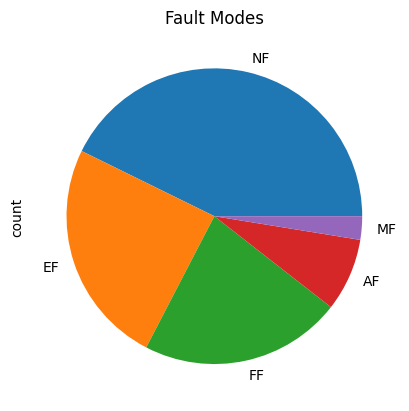

In [25]:
df_final.Fault.value_counts().plot.pie(title='Fault Modes')

In [26]:
df_final.shape

(702, 52)

In [27]:
df_final

,WEC: ava. Rotation,WEC: max. Rotation,WEC: min. Rotation,WEC: ava. Power,WEC: max. Power,WEC: min. Power,WEC: ava. Nacel position including cable twisting,WEC: ava. reactive Power,WEC: max. reactive Power,WEC: min. reactive Power,...,Main carrier temp.,Rectifier cabinet temp.,Yaw inverter cabinet temp.,Fan inverter cabinet temp.,Ambient temp.,Tower temp.,Control cabinet temp.,Transformer temp.,Inverter averages,Fault
0,13.530,15.170,11.160,2210,3099,1044,248,7,22,0,...,22,32,32,35,18,34,43,62,34.727,NF
1,6.630,6.920,6.390,122,164,78,-154,46,47,37,...,23,43,32,37,21,27,36,45,32.727,NF
2,6.320,6.640,5.970,84,125,48,265,36,36,28,...,19,38,28,33,16,24,32,40,29.000,NF
3,7.930,9.580,6.700,345,667,136,-361,41,52,31,...,23,37,30,36,21,30,37,45,32.364,NF
4,7.390,7.600,7.160,101,144,64,-79,39,39,39,...,15,34,24,28,18,18,25,35,26.455,NF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
697,14.690,15.190,13.830,2736,2798,2417,-78,238,243,224,...,14,27,21,24,8,29,35,57,25.909,AF
698,2.530,14.670,0.000,20,2746,0,-76,4,241,0,...,14,27,21,23,7,22,35,57,28.182,AF
699,12.790,13.300,11.640,1667,1914,1259,-66,145,170,119,...,10,23,17,21,5,21,28,42,20.909,AF
700,11.710,13.270,9.990,1311,1945,781,-53,111,155,77,...,10,23,16,20,5,21,28,42,20.909,AF


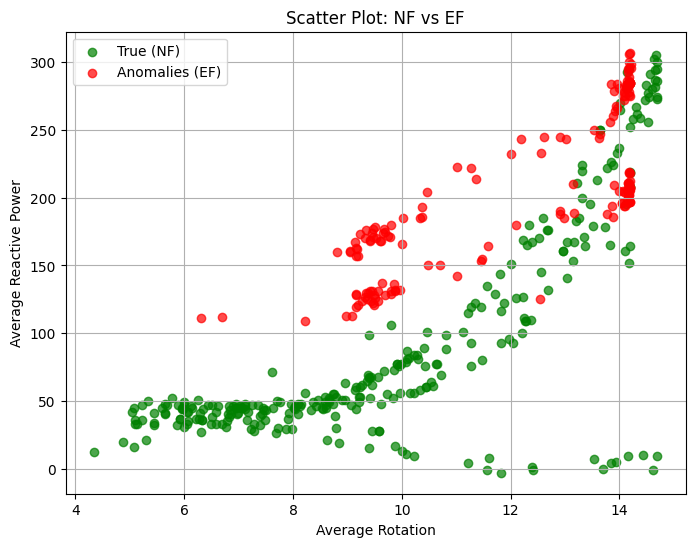

In [39]:
plt.figure(figsize=(8, 6))

# Plot NF (True)
plt.scatter(
    df_final[df_final['Fault'] == 'NF']['WEC: ava. Rotation'],
    df_final[df_final['Fault'] == 'NF']['WEC: ava. reactive Power'],
    color='green', label='True (NF)', alpha=0.7
)

# Plot EF (Anomalies)
plt.scatter(
    df_final[df_final['Fault'] == 'EF']['WEC: ava. Rotation'],
    df_final[df_final['Fault'] == 'EF']['WEC: ava. reactive Power'],
    color='red', label='Anomalies (EF)', alpha=0.7
)

plt.xlabel('Average Rotation')
plt.ylabel('Average Reactive Power')
plt.title('Scatter Plot: NF vs EF')
plt.legend()
plt.grid(True)
plt.show()


In [34]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
df_final.to_csv('/content/drive/My Drive/dataset_anomalies.csv', index=False)